# Sequential logic -- flip-flops, timing, and the leap to computation
### memory + a clock turns gates into a state machine (and an FSM + tape = a Turing machine)

Combinational logic (last notebook: adders, critical paths) has **no memory** -- the
output is a pure function of the present inputs. A **flip-flop** changes that: it
stores a bit and updates only on a clock edge. State + next-state logic = a
**finite-state machine**; add an unbounded tape and you have a **Turing machine** --
the whole of computation. Along the way: **setup/hold** timing (why data must be
stable around the edge), the **maximum clock frequency** (set by the combinational
path between flip-flops), and the fact that a counter **integrates** the clock.
Built on `dgs/logic_timing.py`.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import logic_timing as lt
print("ready")

ready


## 1. The D flip-flop -- a bit of memory

A rising-edge D flip-flop copies its input D to its output Q **only on the clock
edge**, and **holds** Q the rest of the time. That hold is the memory. Below, D
wiggles every step but Q only changes at the (simulated) clock ticks.

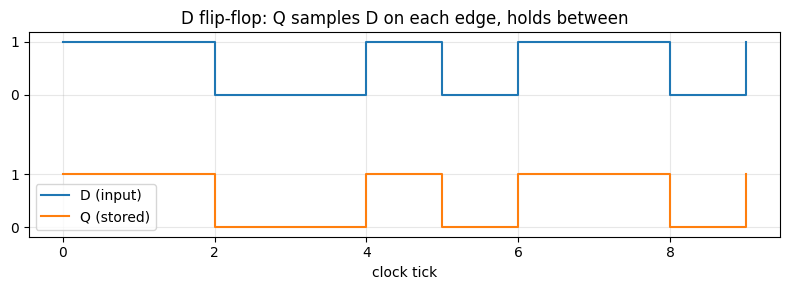

Q = [1, 1, 0, 0, 1, 0, 1, 1, 0, 1]  (each Q[i] = D[i] latched at edge i)


In [2]:
D = [1,1,0,0,1,0,1,1,0,1]
ff = lt.DFlipFlop(q=0)
Q = [ff.tick(d) for d in D]
t = np.arange(len(D))
plt.figure(figsize=(8,3))
plt.step(t, np.array(D)+2.5, where="post", label="D (input)")
plt.step(t, Q, where="post", label="Q (stored)")
plt.yticks([0,1,2.5,3.5], ["0","1","0","1"]); plt.xlabel("clock tick"); plt.legend()
plt.title("D flip-flop: Q samples D on each edge, holds between"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Q =", Q, " (each Q[i] = D[i] latched at edge i)")

## 2. Setup and hold -- data must be stable around the edge

The data has to be steady for $t_{\rm setup}$ **before** the edge and $t_{\rm hold}$
**after** it. Change inside that window and the flip-flop may latch garbage
(metastability). The shaded band is the forbidden zone.

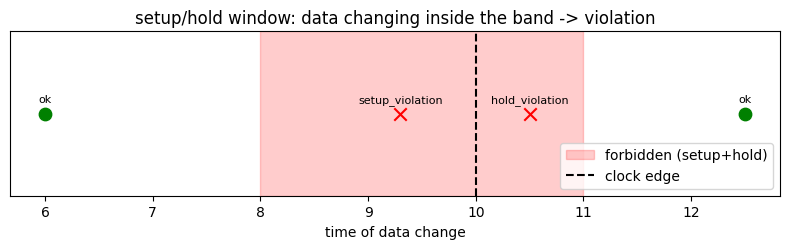

In [3]:
edge, t_su, t_h = 10.0, 2.0, 1.0
plt.figure(figsize=(8,2.6))
plt.axvspan(edge-t_su, edge+t_h, color="red", alpha=0.2, label="forbidden (setup+hold)")
plt.axvline(edge, color="k", ls="--", label="clock edge")
for tc, mk in [(6.0,"o"), (9.3,"x"), (10.5,"x"), (12.5,"o")]:
    status = lt.setup_hold_status(tc, edge, t_su, t_h)
    col = "green" if status=="ok" else "red"
    plt.scatter([tc],[1], color=col, s=80, marker=mk)
    plt.annotate(status, (tc,1), textcoords="offset points", xytext=(0,8), ha="center", fontsize=8)
plt.yticks([]); plt.xlabel("time of data change"); plt.legend(loc="lower right")
plt.title("setup/hold window: data changing inside the band -> violation"); plt.tight_layout(); plt.show()

## 3. Maximum clock frequency -- set by the combinational path

Between two flip-flops the clock period must clear
$$T \ge t_{\rm clk\text{-}q} + t_{\rm comb} + t_{\rm setup},\qquad f_{\max}=1/T.$$
The $t_{\rm comb}$ is the **critical path** from the last notebook. So the ripple
adder's linear delay growth directly **slows the clock** as the adder widens --
which is *why* fast adders matter.

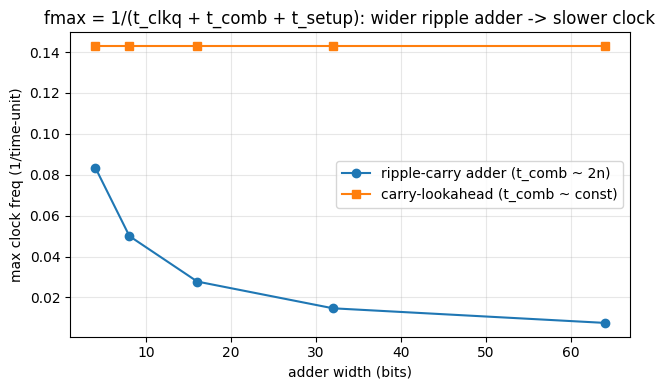

ripple fmax: [0.083, 0.05, 0.028, 0.015, 0.008]  <- falls as the carry chain grows


In [4]:
ns = [4, 8, 16, 32, 64]
fmax = [lt.max_clock_frequency(lt.ripple_carry_delay(n)) for n in ns]
fmax_cla = [lt.max_clock_frequency(lt.carry_lookahead_delay(n)) for n in ns]
plt.figure(figsize=(6.5,4))
plt.plot(ns, fmax, "o-", label="ripple-carry adder (t_comb ~ 2n)")
plt.plot(ns, fmax_cla, "s-", label="carry-lookahead (t_comb ~ const)")
plt.xlabel("adder width (bits)"); plt.ylabel("max clock freq (1/time-unit)")
plt.title("fmax = 1/(t_clkq + t_comb + t_setup): wider ripple adder -> slower clock")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("ripple fmax:", [round(f,3) for f in fmax], " <- falls as the carry chain grows")

## 4. A counter *integrates* the clock

Chain flip-flops into a counter and each clock pulse increments the stored value:
the counter **accumulates** edges. That is discrete **integration** -- the same
"sum up the increments" idea as `numerical_methods.cumulative_integral`, done in
hardware. The staircase is the integral of a constant input rate.

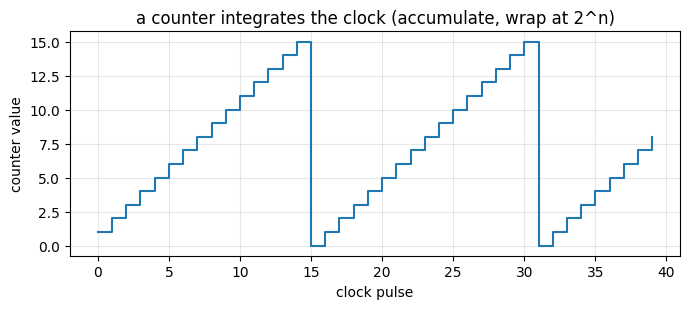

first 10 counts: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (each pulse += 1, mod 16)


In [5]:
vals = lt.ripple_counter(4, 40)        # 4-bit counter, 40 pulses -> sawtooth (mod 16)
plt.figure(figsize=(7,3.2))
plt.step(range(len(vals)), vals, where="post")
plt.xlabel("clock pulse"); plt.ylabel("counter value")
plt.title("a counter integrates the clock (accumulate, wrap at 2^n)"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("first 10 counts:", vals[:10], " (each pulse += 1, mod 16)")

## 5. A finite-state machine -- the bridge to Turing

A **Moore FSM** is flip-flops (the state) plus combinational next-state logic. Here
a 3-state machine raises its output whenever the input stream ends in **`101`**
(overlap-aware). This is the conceptual leap: combinational logic + memory + a clock
= a machine that *remembers context and reacts*. Give an FSM an unbounded tape to
read and write, and it becomes a **Turing machine** -- the model of all computation.

input : [1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
detect: [0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1]  <- 1 wherever the stream just completed '101'


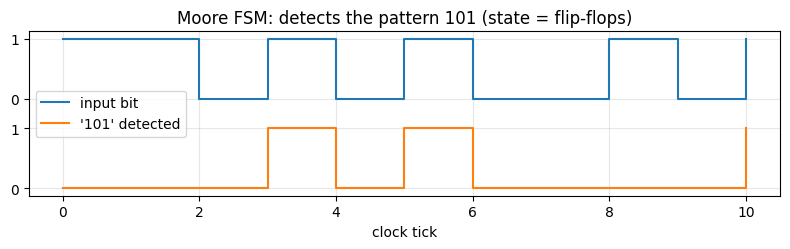

In [6]:
stream = [1,1,0,1,0,1,0,0,1,0,1]
out = lt.sequence_detector_101(stream)
print("input :", stream)
print("detect:", out, " <- 1 wherever the stream just completed '101'")
plt.figure(figsize=(8,2.6))
plt.step(range(len(stream)), stream, where="post", label="input bit")
plt.step(range(len(out)), np.array(out)-1.5, where="post", label="'101' detected")
plt.yticks([0,1,-1.5,-0.5], ["0","1","0","1"]); plt.xlabel("clock tick"); plt.legend()
plt.title("Moore FSM: detects the pattern 101 (state = flip-flops)"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## What you proved

1. A **flip-flop** stores a bit and updates on the clock edge -- memory is what makes
   logic *sequential* rather than a pure function of the inputs.
2. **Setup/hold**: data must be stable around the edge or the flop latches garbage.
3. **fmax** $=1/(t_{\rm clk\text{-}q}+t_{\rm comb}+t_{\rm setup})$ -- the combinational
   critical path (the adder!) sets the clock speed.
4. A **counter integrates** the clock (accumulation = discrete integration).
5. An **FSM** (flip-flops + next-state logic) remembers context; + a tape = a
   **Turing machine**.

That is the whole arc: gates -> timed combinational paths -> clocked state ->
finite-state machines -> computation. Civilian education.